## Entrenamiento final.

In [1]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import json

In [2]:
archivo = "CSVs/parámetros_columnas.json"

with open(archivo, "r") as f:
    datos = json.load(f)
    
mejores_parametros = datos["mejores_parametros"]
x_columnas = datos["x_columnas"]
y_columnas = datos["y_columnas"]

In [3]:
train_viajeros = pd.read_csv("CSVs/train_viajeros.csv")
test_viajeros = pd.read_csv("CSVs/test_viajeros.csv")
prediccion_viajeros = pd.read_csv("CSVs/prediccion_viajeros.csv")
df_verano_viajeros = pd.read_csv("CSVs/verano_viajeros.csv")

In [4]:
categoricas_viajeros = [x_columnas.index("Provincias")]

Se filtra mayo en train y test. Se evaluan solamente los meses de verano.

In [5]:
train_viajeros = train_viajeros[train_viajeros["Mes"].isin([6,7,8])]
test_viajeros = test_viajeros[test_viajeros["Mes"].isin([6,7,8])]

In [6]:
x_train_viajeros = train_viajeros[x_columnas]
y_train_viajeros = train_viajeros[y_columnas]

x_test_viajeros = test_viajeros[x_columnas]
y_test_viajeros = test_viajeros[y_columnas]

## CatBoost

### Evaluación final sobre test.

In [7]:
modelo_test = CatBoostRegressor(
    iterations=1500,
    learning_rate=mejores_parametros["learning_rate"],
    depth =mejores_parametros["depth"] ,
    l2_leaf_reg=mejores_parametros["l2"] ,
    loss_function="RMSE",
    random_seed=42,
    early_stopping_rounds=100,
    verbose=0
)

modelo_test.fit(x_train_viajeros, y_train_viajeros, cat_features=categoricas_viajeros)

prediccion_log = modelo_test.predict(x_test_viajeros)

turistas_pasados = test_viajeros["Turistas_pasados"]
turistas_reales = test_viajeros["Turistas_totales"]

# Predicción CatBoost
ratio = np.exp(prediccion_log)
turistas_p = turistas_pasados * ratio

#Predicció Naive
prediccion_naive = turistas_pasados.fillna(0)


mae_viajeros = mean_absolute_error(turistas_reales, turistas_p)
rmse_viajeros = np.sqrt(mean_squared_error(turistas_reales, turistas_p))

mae_naive = mean_absolute_error(turistas_reales, prediccion_naive)
rmse_naive = np.sqrt(mean_squared_error(turistas_reales, prediccion_naive))

mape_viajeros = np.mean(np.abs(turistas_reales - turistas_p) / (turistas_reales + 1e-6))
precision_viajeros = 100 * (1-mape_viajeros)

mape_naive = np.mean(np.abs(turistas_reales - prediccion_naive) / (turistas_reales + 1e-6))
precision_naive = 100 * (1-mape_naive)

print(f"CATBOOST--- MAE: {mae_viajeros:.3f}, RMSE: {rmse_viajeros:.3f}, PRECISIÓN: {precision_viajeros:.2f}%")
print(f"NAIVE--- MAE: {mae_naive:.3f}, RMSE: {rmse_naive:.3f}, PRECISIÓN: {precision_naive:.2f}%")
      
if rmse_viajeros < rmse_naive:
    diferencia = rmse_naive - rmse_viajeros
    print(f"El modelo CatBoost es mejor.")
else:
    print(f"El modelo CatBoost no super al Naive.")

CATBOOST--- MAE: 5504.513, RMSE: 13776.764, PRECISIÓN: 92.01%
NAIVE--- MAE: 10376.410, RMSE: 23824.057, PRECISIÓN: 85.38%
El modelo CatBoost es mejor.


### Entrenamiento final del modelo.

Entrenamiento final del modelo.

In [8]:
modelo_final_viajeros = CatBoostRegressor(
        iterations=1500,
        learning_rate=mejores_parametros["learning_rate"],
        depth=mejores_parametros["depth"],
        l2_leaf_reg=mejores_parametros["l2"],
        loss_function="RMSE",
        random_seed=42,
        early_stopping_rounds=100,
        verbose=200
    )

modelo_final_viajeros.fit(x_train_viajeros, y_train_viajeros, cat_features=categoricas_viajeros)

0:	learn: 0.1986456	total: 35.5ms	remaining: 53.2s
200:	learn: 0.1240809	total: 5.51s	remaining: 35.6s
400:	learn: 0.1019705	total: 11s	remaining: 30.1s
600:	learn: 0.0859353	total: 16.9s	remaining: 25.2s
800:	learn: 0.0745431	total: 22.3s	remaining: 19.5s
1000:	learn: 0.0642803	total: 27.7s	remaining: 13.8s
1200:	learn: 0.0561191	total: 33s	remaining: 8.22s
1400:	learn: 0.0503412	total: 38.4s	remaining: 2.71s
1499:	learn: 0.0477551	total: 41s	remaining: 0us


In [9]:
df_verano_viajeros = df_verano_viajeros.sort_values(["Provincias", "Año", "Mes"]).reset_index(drop=True)

# Se incluye el mes de mayo en "meses_verano" para predecirlo y que junio tenga un mes anterior de referencia.
meses_verano = [5, 6,7,8]

for mes in meses_verano:
    grupo = df_verano_viajeros.groupby("Provincias")["Turistas_totales"]

    df_verano_viajeros["Turistas_pasados"] = grupo.shift(1)

    for lag in [1,2,3,4]:
        df_verano_viajeros[f"lag_{lag}"] = grupo.shift(lag)

        df_verano_viajeros[f"log_lag_{lag}"] = np.log1p(df_verano_viajeros[f"lag_{lag}"].fillna(0))

    df_verano_viajeros["media_lag_2"] = (df_verano_viajeros["log_lag_1"] + df_verano_viajeros["log_lag_2"]) / 2

    df_verano_viajeros["media_lag_3"] = (df_verano_viajeros["log_lag_1"] +
                                    df_verano_viajeros["log_lag_2"] +
                                    df_verano_viajeros["log_lag_3"]) / 3

    df_verano_viajeros["tendencia_corta"] = df_verano_viajeros["log_lag_1"] - df_verano_viajeros["log_lag_2"]

    mask_mes = ((df_verano_viajeros["Año"] == 2026) & (df_verano_viajeros["Mes"] == mes))

    prediccion_log_ratio = modelo_final_viajeros.predict(df_verano_viajeros.loc[mask_mes, x_columnas])

    ratio_final = np.exp(prediccion_log_ratio)

    valor = (df_verano_viajeros.loc[mask_mes, "Turistas_pasados"] * ratio_final)

    df_verano_viajeros.loc[mask_mes, "Turistas_totales"] = valor


Predicción final.

In [10]:
# Se excluye el mes de mayo.

df_verano_2026 = df_verano_viajeros[(df_verano_viajeros["Año"] == 2026) & (df_verano_viajeros["Mes"].isin([6,7,8]))].copy()

df_verano_2026["Predicciones"] = df_verano_2026["Turistas_totales"]

prediccion_verano_viajeros = (df_verano_2026.groupby("Provincias")["Predicciones"].sum().reset_index().sort_values(by="Predicciones", ascending=False))

prediccion_verano_viajeros


,Provincias,Predicciones
24,Illes Balears,6.990024e+06
7,Barcelona,3.667842e+06
31,Madrid,1.603836e+06
27,Las Palmas,1.406325e+06
19,Girona,1.311176e+06
34,Málaga,1.165824e+06
2,Alicante/Alacant,9.312815e+05
40,Santa Cruz de Tenerife,8.781526e+05
44,Tarragona,7.706684e+05
47,Valencia/València,5.398208e+05


Visualización.

In [11]:
df_tabla = prediccion_verano_viajeros.copy()

df_tabla["Predicciones"] = df_tabla["Predicciones"].apply(
    lambda x: f"{x:,.0f}".replace(",", ".")
)

division = int(np.ceil(len(df_tabla)/4))
columna_1 = df_tabla.iloc[:division].reset_index(drop=True)
columna_2 = df_tabla.iloc[division:2*division].reset_index(drop=True)
columna_3 = df_tabla.iloc[2*division:3*division].reset_index(drop=True)
columna_4 = df_tabla.iloc[3*division:].reset_index(drop=True)

df_tabla_final = pd.concat([columna_1, columna_2, columna_3, columna_4], axis=1)
df_tabla_final.columns = ["Provincias", "Turistas", "Provincias", "Turistas", "Provincias", "Turistas", "Provincias", "Turistas"]

df_tabla_final 

,Provincias,Turistas,Provincias,Turistas,Provincias,Turistas,Provincias,Turistas
0,Illes Balears,6.990.024,Granada,236.299,Córdoba,104.495,Ciudad Real,16.359
1,Barcelona,3.667.842,Cádiz,220.094,Castellón/Castelló,90.450,Jaén,15.389
2,Madrid,1.603.836,Pontevedra,219.565,Huesca,83.515,Ourense,14.883
3,Las Palmas,1.406.325,A Coruña,192.837,Lleida,73.619,Palencia,14.847
4,Girona,1.311.176,Asturias,163.885,Araba/Álava,69.361,Teruel,14.110
5,Málaga,1.165.824,Burgos,143.522,Badajoz,67.905,Ávila,11.875
6,Alicante/Alacant,931.281,Huelva,134.404,Valladolid,65.840,Albacete,11.740
7,Santa Cruz de Tenerife,878.153,Zaragoza,134.019,Lugo,62.093,Melilla,9.917
8,Tarragona,770.668,Almería,131.768,Toledo,58.552,Ceuta,9.353
9,Valencia/València,539.821,Cantabria,129.837,León,52.358,Guadalajara,7.957


In [12]:
df_tabla_final.to_excel("../graficos/tabla_catboost_2.xlsx", index=False)

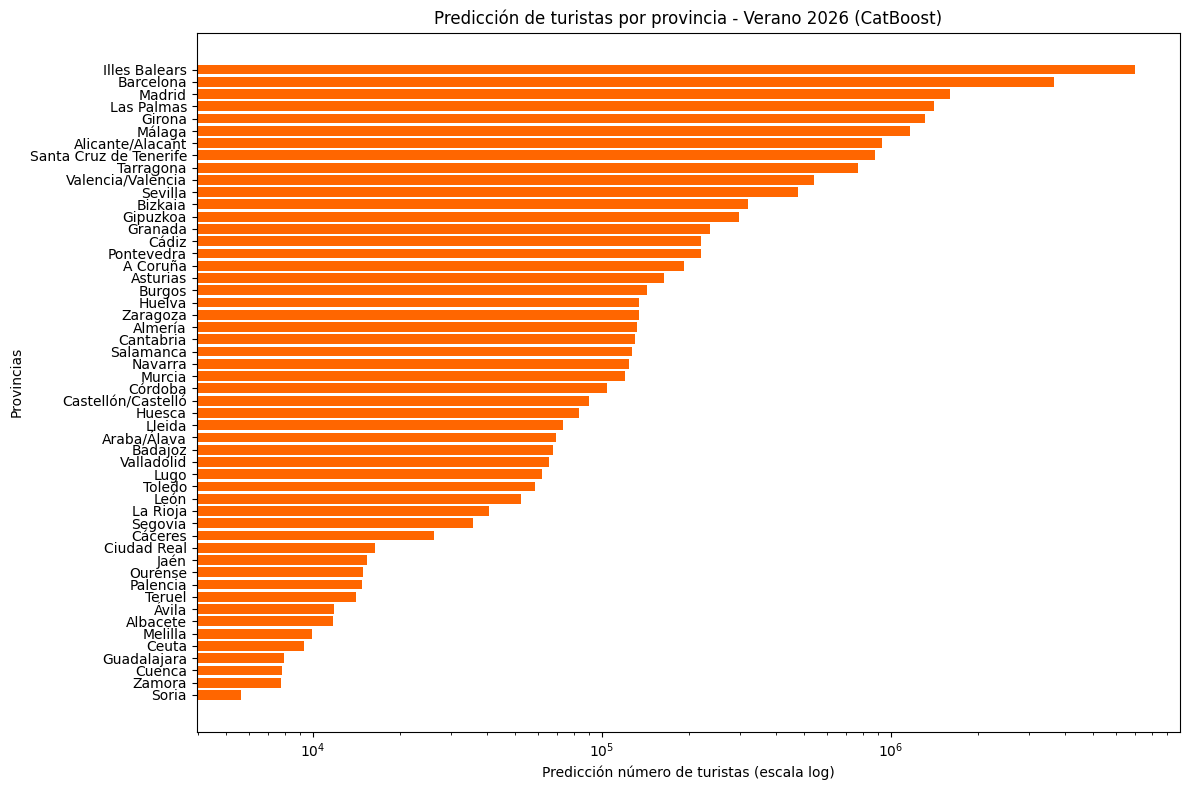

In [13]:
plt.figure(figsize=(12,8))
plt.barh(prediccion_verano_viajeros["Provincias"], prediccion_verano_viajeros["Predicciones"], color= "#ff6600")
plt.gca().invert_yaxis()
plt.xscale("log")
plt.xlabel("Predicción número de turistas (escala log)")
plt.ylabel("Provincias")
plt.title("Predicción de turistas por provincia - Verano 2026 (CatBoost)")
plt.tight_layout()
plt.show()